In [1]:
print("Hello World")

Hello World


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score


In [3]:
np.random.seed(42)
train = pd.DataFrame({
    "age":np.random.normal(35,8,1000),
    "salary":np.random.normal(50000,10000,1000)
})
train.to_csv("train_data.csv",index=False)

In [4]:
prod = pd.DataFrame({
    "age":np.random.normal(35,8,1000),
    "salary":np.random.normal(70000,12000,1000)
})
prod.to_csv("prod_data.csv",index=False)

In [ ]:
# K-S Test

from scipy.stats import ks_2samp

ks_stat,p_value = ks_2samp( train["salary"], prod["salary"])
print("Ks_statistic : ",ks_stat)
print("P-Value : ",p_value)

if p_value < 0.05:
    print("Drift Detected !")
else:
    print("No Drift Detected !")

Ks_statistic :  0.607
P-Value :  5.457544652822024e-172
Drift Detected !


In [7]:
# PSI Test

def calculate_psi(expected, actual, buckets=10):

    breakpoints = np.linspace(0, 100, buckets + 1)

    expected_bins = np.percentile(expected, breakpoints)

    expected_perc = np.histogram(expected, bins=expected_bins)[0] / len(expected)
    actual_perc = np.histogram(actual, bins=expected_bins)[0] / len(actual)

    expected_perc = np.where(expected_perc == 0, 0.0001, expected_perc)
    actual_perc = np.where(actual_perc == 0, 0.0001, actual_perc)

    psi = np.sum((actual_perc - expected_perc) *
                 np.log(actual_perc / expected_perc))

    return psi

psi_score = calculate_psi(
    train["salary"],
    prod["salary"]
)

print("PSI:", psi_score)

PSI: 1.887688100342805


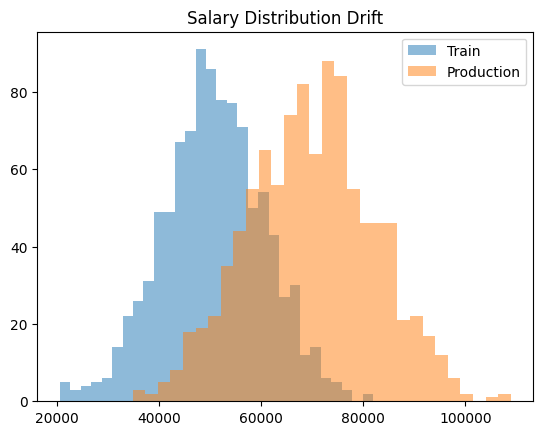

In [ ]:
plt.hist(train["salary"], bins=30, alpha=0.5, label="Train")
plt.hist(prod["salary"], bins=30, alpha=0.5, label="Production")

plt.legend()
plt.title("Salary Distribution Drift")
plt.show()

In [ ]:
#Concept Drift 

X_train = np.random.rand(1000,2)
y_train = (X_train[:,0] + X_train[:,1] > 1).astype(int)

model = LogisticRegression()
model.fit(X_train,y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
pred = model.predict(X_train)
print("Training Accuracy:",accuracy_score(y_train,pred))


Training Accuracy: 0.995


In [23]:
X_prod = np.random.rand(1000,2)

y_prod = (X_prod[:,0] > 0.8).astype(int)

pred_prod = model.predict(X_prod)

print("Production Accuracy:",accuracy_score(y_prod,pred_prod))

Production Accuracy: 0.667
